In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import re
import random
import hashlib
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
random.seed(42)

print('All imports successful!')

All imports successful!


In [2]:
# ----- LOAD DATA -----
df = pd.read_csv('RecipeReviews.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


In [3]:
# Data clean up
print('=== Data Types & Non-Null Counts ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
# Statistic names
df[['stars', 'thumbs_up', 'reply_count', 'user_reputation']].describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       18182 non-null  int64 
 1   recipe_number    18182 non-null  int64 
 2   recipe_code      18182 non-null  int64 
 3   recipe_name      18182 non-null  object
 4   comment_id       18182 non-null  object
 5   user_id          18182 non-null  object
 6   user_name        18182 non-null  object
 7   user_reputation  18182 non-null  int64 
 8   created_at       18182 non-null  int64 
 9   reply_count      18182 non-null  int64 
 10  thumbs_up        18182 non-null  int64 
 11  thumbs_down      18182 non-null  int64 
 12  stars            18182 non-null  int64 
 13  best_score       18182 non-null  int64 
 14  text             18180 non-null  object
dtypes: int64(10), object(5)
memory usage: 2.1+ MB
None

=== Missing Values ===
Unnamed: 

,stars,thumbs_up,reply_count,user_reputation
count,18182.000000,18182.000000,18182.000000,18182.000000
mean,4.288802,1.089264,0.014630,2.159608
std,1.544786,4.201004,0.137974,10.014666
min,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,1.000000
50%,5.000000,0.000000,0.000000,1.000000
75%,5.000000,0.000000,0.000000,1.000000
max,5.000000,106.000000,3.000000,520.000000


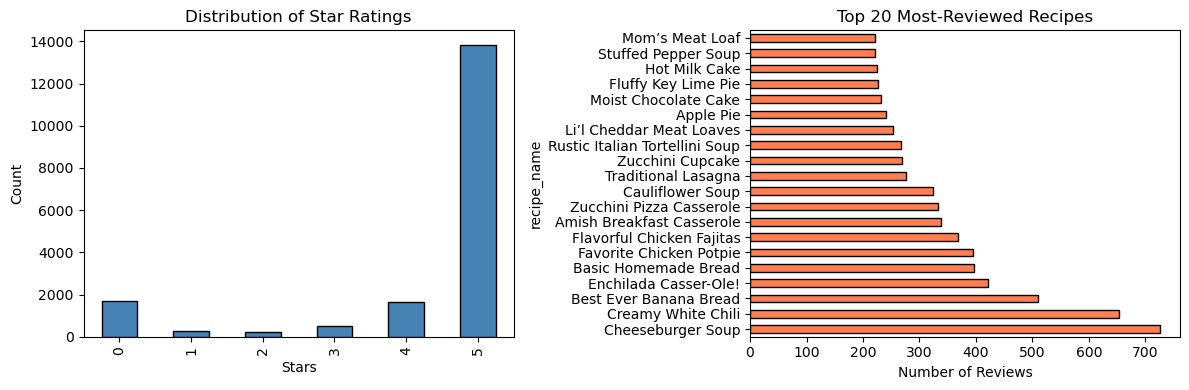

In [4]:
# Distribution of star ratings
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Star Ratings')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

# Ratings per recipe (top 20)
recipe_counts = df['recipe_name'].value_counts().head(20)
recipe_counts.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 20 Most-Reviewed Recipes')
axes[1].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

Avg ratings per user: 1.32
Median ratings per user: 1.00
Users with only 1 rating: 11700


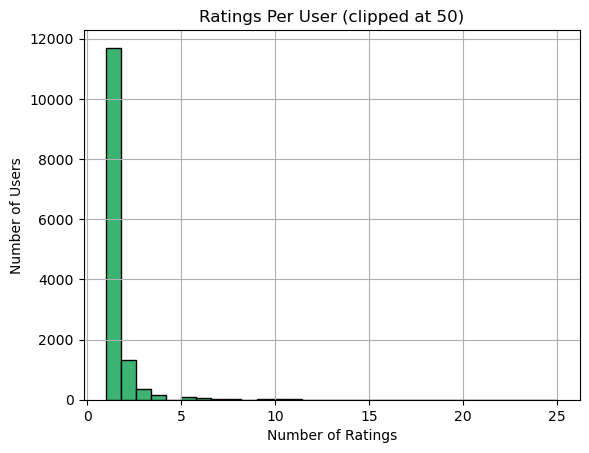

In [5]:
#User rating counts
ratings_per_user = df.groupby('user_id').size()
print(f'Avg ratings per user: {ratings_per_user.mean():.2f}')
print(f'Median ratings per user: {ratings_per_user.median():.2f}')
print(f'Users with only 1 rating: {(ratings_per_user == 1).sum()}')

ratings_per_user.clip(upper=50).hist(bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Ratings Per User (clipped at 50)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

In [6]:
#2. Data Cleaning & Preproccessing

In [7]:
# Drop rows missing data
df_clean = df.dropna(subset=['user_id', 'recipe_name', 'stars']).copy()

# Ensure # stars is valid
df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
df_clean = df_clean[df_clean['stars'].between(1, 5)]

# Convert user_id and recipe_name to string
df_clean['user_id'] = df_clean['user_id'].astype(str)
df_clean['recipe_name'] = df_clean['recipe_name'].astype(str)

#take mean of ratings
df_clean = df_clean.groupby(['user_id', 'recipe_name'], as_index=False)['stars'].mean()

print(f'Clean dataset shape: {df_clean.shape}')
print(f'Unique users: {df_clean["user_id"].nunique()}')
print(f'Unique recipes: {df_clean["recipe_name"].nunique()}')

Clean dataset shape: (15795, 3)
Unique users: 12420
Unique recipes: 100


In [8]:
# -----------------------------------------------------------------------
# SPARSITY FILTER
# -----------------------------------------------------------------------
MIN_USER_RATINGS   = 5   
MIN_RECIPE_RATINGS = 10 

def filter_sparse(df, min_user, min_recipe):
    while True:
        user_counts   = df.groupby('user_id')['recipe_name'].count()
        recipe_counts = df.groupby('recipe_name')['user_id'].count()
        active_users   = user_counts[user_counts   >= min_user].index
        active_recipes = recipe_counts[recipe_counts >= min_recipe].index
        df_filtered = df[df['user_id'].isin(active_users) & df['recipe_name'].isin(active_recipes)]
        if len(df_filtered) == len(df): 
            break
        df = df_filtered
    return df_filtered

df_filtered = filter_sparse(df_clean, MIN_USER_RATINGS, MIN_RECIPE_RATINGS)

print(f'Filtered dataset shape: {df_filtered.shape}')
print(f'Unique users after filter:   {df_filtered["user_id"].nunique()}')
print(f'Unique recipes after filter: {df_filtered["recipe_name"].nunique()}')

n_users   = df_filtered['user_id'].nunique()
n_recipes = df_filtered['recipe_name'].nunique()
sparsity  = 1 - len(df_filtered) / (n_users * n_recipes)
print(f'Matrix sparsity: {sparsity:.4%}')

Filtered dataset shape: (1556, 3)
Unique users after filter:   202
Unique recipes after filter: 78
Matrix sparsity: 90.1244%


In [9]:
#3. Building the User-Recipe rating 

In [10]:
rating_matrix = df_filtered.pivot(index='user_id', columns='recipe_name', values='stars')

print(f'Rating matrix shape: {rating_matrix.shape}')
print(f'Non-null entries: {rating_matrix.notna().sum().sum()}')
rating_matrix.head()

Rating matrix shape: (202, 78)
Non-null entries: 1556


recipe_name,Amish Breakfast Casserole,Apple Pie,Asian Chicken Thighs,Bacon Macaroni Salad,Baked Mushroom Chicken,Baked Spaghetti,Baked Tilapia,Banana Bars with Cream Cheese Frosting,Basic Banana Muffins,Best Ever Banana Bread,...,Strawberry Pretzel Salad,Stuffed Pepper Soup,Taco Lasagna,Tennessee Peach Pudding,Teriyaki Chicken Thighs,Traditional Lasagna,White Bean Chicken Chili,Winning Apple Crisp,Zucchini Cupcake,Zucchini Pizza Casserole
user_id,,,,,,,,,,,,,,,,,,,,,
u_1oKVZPP8jYZRYPrNWRdDSTevmF4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,5.0,...,NaN,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,4.0
u_1oKVZTHTqi7N4NPqNxPS2XB2asz,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
u_1oKVZTi0UOjTtdNBtFIYYHyN2x6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
u_1oKVZUMDcz6fqhcfNkITken7Qof,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


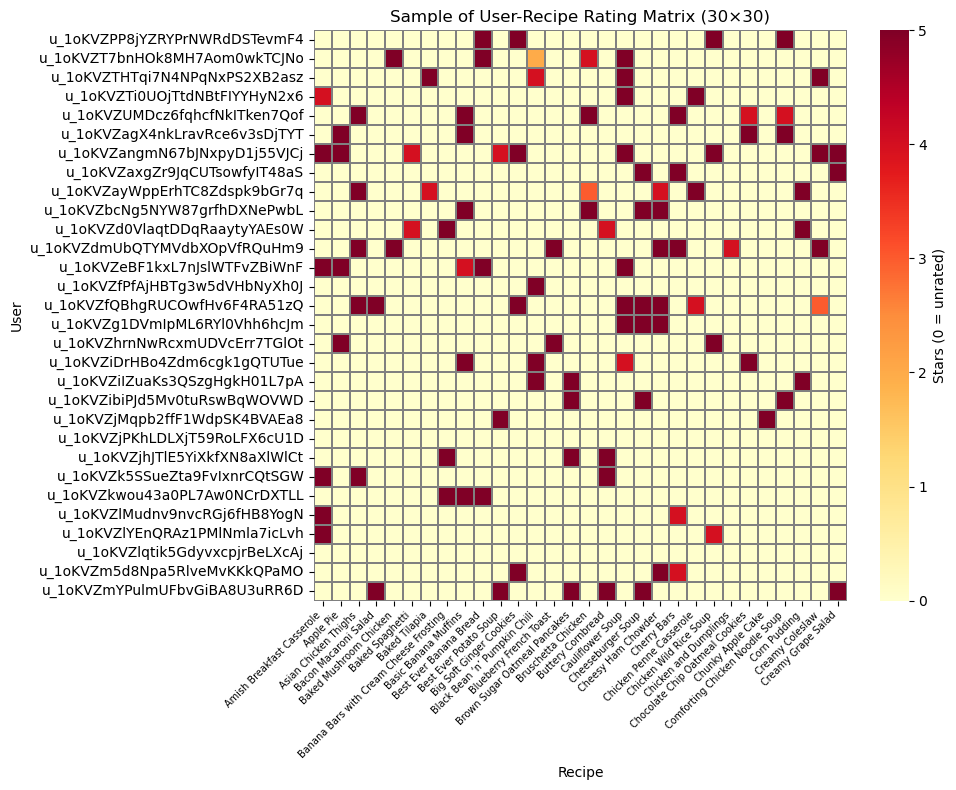

In [11]:
sample = rating_matrix.iloc[:30, :30].fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(sample, cmap='YlOrRd', linewidths=0.1, linecolor='grey', cbar_kws={'label': 'Stars (0 = unrated)'})
plt.title('Sample of User-Recipe Rating Matrix (30×30)')
plt.xlabel('Recipe')
plt.ylabel('User')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [12]:
#4. Collaborative Filtering (User-Based)

In [13]:
rating_matrix_filled = rating_matrix.fillna(0)


user_similarity = cosine_similarity(rating_matrix_filled)
user_sim_df = pd.DataFrame(
    user_similarity,
    index=rating_matrix.index,
    columns=rating_matrix.index
)

print(f'User similarity matrix shape: {user_sim_df.shape}')
print(f'Sample similarities for first user:')
print(user_sim_df.iloc[0].sort_values(ascending=False).head(6))

def cf_recommend(user_id, rating_matrix, user_sim_df, K=10, N=10):
    """
    User-based collaborative filtering recommender.

    Parameters
    ----------
    user_id       : the target user
    rating_matrix : full user x recipe matrix (NaN for unrated)
    user_sim_df   : precomputed user-user cosine similarity DataFrame
    K             : number of nearest neighbors to consider
    N             : number of top recommendations to return

    Returns
    -------
    DataFrame of top-N recommended recipes with predicted scores
    """
    if user_id not in rating_matrix.index:
        raise ValueError(f'User {user_id} not found in rating matrix.')

    sim_scores = user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    top_k_users = sim_scores.head(K).index.tolist()
    top_k_sims  = sim_scores.head(K).values

    rated_recipes = rating_matrix.loc[user_id].dropna().index.tolist()

    neighbor_ratings = rating_matrix.loc[top_k_users]
    candidate_recipes = [r for r in neighbor_ratings.columns if r not in rated_recipes]

    predictions = {}
    for recipe in candidate_recipes:
        recipe_ratings = neighbor_ratings[recipe]
        mask = recipe_ratings.notna()
        if mask.sum() == 0:
            continue
        weights = top_k_sims[mask.values]
        if weights.sum() == 0:
            continue
        pred = np.dot(weights, recipe_ratings[mask]) / weights.sum()
        predictions[recipe] = pred

    recs = pd.DataFrame(predictions.items(), columns=['recipe_name', 'predicted_stars'])
    recs = recs.sort_values('predicted_stars', ascending=False).head(N).reset_index(drop=True)
    return recs

User similarity matrix shape: (202, 202)
Sample similarities for first user:
user_id
u_1oKVZPP8jYZRYPrNWRdDSTevmF4    1.000000
u_1oKVZoToVmKg9kqZJaYvVAhSJye    0.382880
u_1oKVeFd6NQn9S2MPiWHWuA9ecjg    0.350931
u_1oKVaBmiEKwAFyiHrDLoWpbel0J    0.308607
u_1oKVlSUIbWEOUoajBNtwpsR6ElO    0.308607
u_1oKVZpdzBp5PQHOM4PGQOZo1ujc    0.293357
Name: u_1oKVZPP8jYZRYPrNWRdDSTevmF4, dtype: float64


In [14]:
sample_user = rating_matrix.index[0]  
print(f'Generating CF recommendations for user: {sample_user}')
print(f'\nRecipes this user has rated:')
print(rating_matrix.loc[sample_user].dropna().sort_values(ascending=False))

print(f'\nTop-10 CF Recommendations:')
cf_recs = cf_recommend(sample_user, rating_matrix, user_sim_df, K=10, N=10)
print(cf_recs)

Generating CF recommendations for user: u_1oKVZPP8jYZRYPrNWRdDSTevmF4

Recipes this user has rated:
recipe_name
Best Ever Banana Bread            5.0
Big Soft Ginger Cookies           5.0
Chicken Wild Rice Soup            5.0
Comforting Chicken Noodle Soup    5.0
Easy Chicken Enchiladas           5.0
Favorite Dutch Apple Pie          5.0
Fluffy Pancakes                   5.0
Name: u_1oKVZPP8jYZRYPrNWRdDSTevmF4, dtype: float64

Top-10 CF Recommendations:
                              recipe_name  predicted_stars
0               Grilled Huli Huli Chicken              5.0
1               Amish Breakfast Casserole              5.0
2  Banana Bars with Cream Cheese Frosting              5.0
3                               Apple Pie              5.0
4            Brown Sugar Oatmeal Pancakes              5.0
5                      Bruschetta Chicken              5.0
6                       Cheeseburger Soup              5.0
7                   Best Ever Potato Soup              5.0
8          

In [15]:
#5. SVD- Based 

In [16]:
rating_matrix_centered = rating_matrix.subtract(user_means, axis=0).fillna(0)

R = rating_matrix_centered.values

print(f'Rating matrix shape passed to SVD: {R.shape}')

Rating matrix shape passed to SVD: (202, 78)


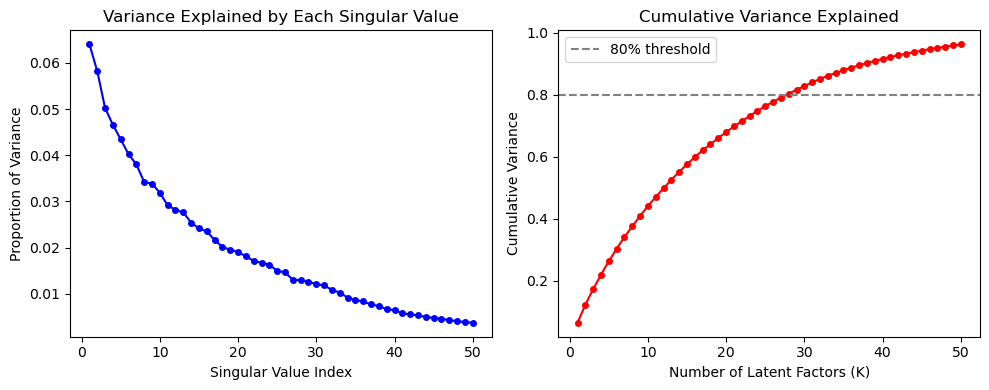

K needed to explain 80% of variance: 28


In [17]:
U_full, sigma_full, Vt_full = np.linalg.svd(R, full_matrices=False)


variance_explained = (sigma_full ** 2) / np.sum(sigma_full ** 2)
cumulative_variance = np.cumsum(variance_explained)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(sigma_full[:50])+1), variance_explained[:50], 'bo-', markersize=4)
plt.title('Variance Explained by Each Singular Value')
plt.xlabel('Singular Value Index')
plt.ylabel('Proportion of Variance')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance[:50])+1), cumulative_variance[:50], 'ro-', markersize=4)
plt.axhline(0.8, color='grey', linestyle='--', label='80% threshold')
plt.title('Cumulative Variance Explained')
plt.xlabel('Number of Latent Factors (K)')
plt.ylabel('Cumulative Variance')
plt.legend()

plt.tight_layout()
plt.show()


K_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f'K needed to explain 80% of variance: {K_80}')

In [18]:
K = min(K_80, 50)  
print(f'Using K = {K} latent factors')

U, sigma, Vt = svds(csr_matrix(R), k=K)


sigma_diag = np.diag(sigma)
R_predicted_centered = np.dot(np.dot(U, sigma_diag), Vt)


R_predicted = R_predicted_centered + user_means.values.reshape(-1, 1)


R_predicted = np.clip(R_predicted, 1, 5)


svd_predictions_df = pd.DataFrame(
    R_predicted,
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

print(f'SVD prediction matrix shape: {svd_predictions_df.shape}')
print('Sample predictions (first 5 users, first 5 recipes):')
print(svd_predictions_df.iloc[:5, :5].round(2))

Using K = 28 latent factors
SVD prediction matrix shape: (202, 78)
Sample predictions (first 5 users, first 5 recipes):
recipe_name                    Amish Breakfast Casserole  Apple Pie  \
user_id                                                               
u_1oKVZPP8jYZRYPrNWRdDSTevmF4                       5.00       5.00   
u_1oKVZT7bnHOk8MH7Aom0wkTCJNo                       4.34       4.37   
u_1oKVZTHTqi7N4NPqNxPS2XB2asz                       4.74       4.80   
u_1oKVZTi0UOjTtdNBtFIYYHyN2x6                       4.46       4.83   
u_1oKVZUMDcz6fqhcfNkITken7Qof                       4.18       4.28   

recipe_name                    Asian Chicken Thighs  Bacon Macaroni Salad  \
user_id                                                                     
u_1oKVZPP8jYZRYPrNWRdDSTevmF4                  5.00                  5.00   
u_1oKVZT7bnHOk8MH7Aom0wkTCJNo                  4.38                  4.50   
u_1oKVZTHTqi7N4NPqNxPS2XB2asz                  4.77                  4.82 

In [19]:
def svd_recommend(user_id, rating_matrix, svd_predictions_df, N=10):
    """
    SVD-based recommender.
    Recommends recipes the user has NOT rated, sorted by predicted score.
    """
    if user_id not in rating_matrix.index:
        raise ValueError(f'User {user_id} not found.')

    rated_recipes = rating_matrix.loc[user_id].dropna().index

    user_preds = svd_predictions_df.loc[user_id].drop(labels=rated_recipes, errors='ignore')
    top_n = user_preds.sort_values(ascending=False).head(N)

    return pd.DataFrame({'recipe_name': top_n.index, 'predicted_stars': top_n.values}).reset_index(drop=True)

In [34]:
svd_recs = svd_recommend(sample_user, rating_matrix, svd_predictions_df, N=10)

In [35]:
# 6. Content-Based Filtering (Shingling + MinHash)

In [36]:
recipe_text = (
    df[df['recipe_name'].isin(df_filtered['recipe_name'])]
    .groupby('recipe_name')['text']
    .apply(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

print(f'Recipes with text: {len(recipe_text)}')
print(recipe_text.head())

Recipes with text: 78
                 recipe_name  \
0  Amish Breakfast Casserole   
1                  Apple Pie   
2       Asian Chicken Thighs   
3       Bacon Macaroni Salad   
4     Baked Mushroom Chicken   

                                                text  
0  I am not a fan of cottage cheese at all outsid...  
1  I enjoy all of your recipes I will try this on...  
2  Amazing! I don&#39;t have five spice so I used...  
3  This dish was delicious and one I will make ag...  
4  Fabulous!  Friends said it was restaurant qual...  


In [37]:
def clean_text(text):
    """Lowercase and remove punctuation/extra whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def shingle(text, k=3):
    """
    Generate k-shingles (character-level) from text.
    Returns a Python set of shingle strings.
    """
    text = clean_text(text)
    return set(text[i:i+k] for i in range(len(text) - k + 1))


K_SHINGLE = 5  

recipe_text['shingles'] = recipe_text['text'].apply(lambda t: shingle(t, k=K_SHINGLE))


example = recipe_text.iloc[0]
print(f"Recipe: {example['recipe_name']}")
print(f"Number of unique {K_SHINGLE}-shingles: {len(example['shingles'])}")
print(f"Sample shingles: {list(example['shingles'])[:10]}")

Recipe: Amish Breakfast Casserole
Number of unique 5-shingles: 16238
Sample shingles: ['lotfo', 'y eve', 'ike s', 't 20 ', 'ad so', 'reggi', 'd fam', 'rkers', 'e def', 'as we']


In [38]:
# -----------------------------------------------------------------------
# MinHash: Create compact signatures to approximate Jaccard similarity
# -----------------------------------------------------------------------
NUM_HASHES = 100  


all_shingles = set()
for s_set in recipe_text['shingles']:
    all_shingles.update(s_set)

shingle_to_idx = {s: i for i, s in enumerate(sorted(all_shingles))}
VOCAB_SIZE = len(shingle_to_idx)
print(f'Total unique shingles in vocabulary: {VOCAB_SIZE}')

Total unique shingles in vocabulary: 100628


In [39]:
def make_hash_params(num_hashes, vocab_size, seed=42):
    """
    Generate random (a, b) pairs for universal hash functions:
      h(x) = (a*x + b) % p  where p is a large prime.
    """
    rng = np.random.RandomState(seed)
    p = 2**31 - 1
    a = rng.randint(1, p, size=num_hashes)
    b = rng.randint(0, p, size=num_hashes)
    return a, b, p

def minhash_signature(shingle_set, shingle_to_idx, a, b, p):
    """
    Compute the MinHash signature for a single document.
    Returns a 1-D numpy array of length num_hashes.
    """
    indices = np.array([shingle_to_idx[s] for s in shingle_set if s in shingle_to_idx])
    if len(indices) == 0:
        return np.full(len(a), np.inf)
    hashed = (np.outer(indices, a) + b) % p   
    return hashed.min(axis=0)                 


a, b, p = make_hash_params(NUM_HASHES, VOCAB_SIZE)


print('Computing MinHash signatures...')
signatures = []
for shingle_set in recipe_text['shingles']:
    sig = minhash_signature(shingle_set, shingle_to_idx, a, b, p)
    signatures.append(sig)

signature_matrix = np.array(signatures)  
print(f'Signature matrix shape: {signature_matrix.shape}')

Computing MinHash signatures...
Signature matrix shape: (78, 100)


In [40]:
def jaccard_from_minhash(sig1, sig2):
    """Estimate Jaccard similarity from two MinHash signatures."""
    return np.mean(sig1 == sig2)

def content_recommend(recipe_name, recipe_text_df, signature_matrix, N=10):
    """
    Content-based recommender using MinHash similarity.
    Given a recipe name, return the N most similar recipes by Jaccard similarity.
    """
    if recipe_name not in recipe_text_df['recipe_name'].values:
        raise ValueError(f'Recipe "{recipe_name}" not found.')

    idx = recipe_text_df[recipe_text_df['recipe_name'] == recipe_name].index[0]
    target_sig = signature_matrix[idx]

    similarities = []
    for i, row in recipe_text_df.iterrows():
        if i == idx:
            continue
        sim = jaccard_from_minhash(target_sig, signature_matrix[i])
        similarities.append((row['recipe_name'], sim))

    recs = pd.DataFrame(similarities, columns=['recipe_name', 'jaccard_similarity'])
    return recs.sort_values('jaccard_similarity', ascending=False).head(N).reset_index(drop=True)

In [41]:

popular_recipe = recipe_text['recipe_name'].value_counts().index[0] 
print(f'Top-10 Content-Based Recommendations similar to: "{popular_recipe}"')

cb_recs = content_recommend(popular_recipe, recipe_text, signature_matrix, N=10)
print(cb_recs)

Top-10 Content-Based Recommendations similar to: "Amish Breakfast Casserole"
                      recipe_name  jaccard_similarity
0                 Ravioli Lasagna                0.39
1        Zucchini Pizza Casserole                0.36
2       Flavorful Chicken Fajitas                0.32
3             Stuffed Pepper Soup                0.32
4                       Apple Pie                0.31
5             Slow-Cooker Lasagna                0.31
6                    Taco Lasagna                0.31
7               Cheeseburger Soup                0.31
8  Rustic Italian Tortellini Soup                0.31
9             Forgotten Jambalaya                0.30


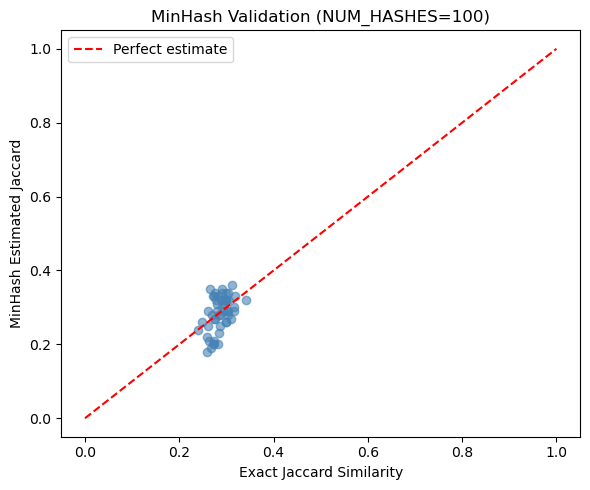

Mean Absolute Error of MinHash estimate: 0.0345


In [42]:
# -----------------------------------------------------------------------
# Validate MinHash: Compare estimated Jaccard vs exact Jaccard on sample
# -----------------------------------------------------------------------
N_VALIDATE = 50 

rng = np.random.RandomState(42)
idxs = rng.choice(len(recipe_text), size=(N_VALIDATE, 2), replace=True)

exact_jaccards    = []
estimated_jaccards = []

for i, j in idxs:
    s1 = recipe_text.iloc[i]['shingles']
    s2 = recipe_text.iloc[j]['shingles']
    if len(s1 | s2) == 0:
        continue
    exact    = len(s1 & s2) / len(s1 | s2)
    estimated = jaccard_from_minhash(signature_matrix[i], signature_matrix[j])
    exact_jaccards.append(exact)
    estimated_jaccards.append(estimated)

plt.figure(figsize=(6, 5))
plt.scatter(exact_jaccards, estimated_jaccards, alpha=0.6, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect estimate')
plt.xlabel('Exact Jaccard Similarity')
plt.ylabel('MinHash Estimated Jaccard')
plt.title(f'MinHash Validation (NUM_HASHES={NUM_HASHES})')
plt.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(np.array(exact_jaccards) - np.array(estimated_jaccards)))
print(f'Mean Absolute Error of MinHash estimate: {mae:.4f}')

In [43]:
#7. Evaluation & Comparison

In [44]:
train_df, test_df = train_test_split(df_filtered, test_size=0.2, random_state=42)

In [45]:

train_matrix = train_df.pivot(index='user_id', columns='recipe_name', values='stars').reindex(
    index=rating_matrix.index, columns=rating_matrix.columns
)


user_means_train = train_matrix.mean(axis=1)
train_centered   = train_matrix.subtract(user_means_train, axis=0).fillna(0).values

K_eval = min(K, min(train_centered.shape) - 1)
U_t, sigma_t, Vt_t = svds(csr_matrix(train_centered), k=K_eval)
R_pred_eval = np.dot(np.dot(U_t, np.diag(sigma_t)), Vt_t) + user_means_train.values.reshape(-1, 1)
R_pred_eval = np.clip(R_pred_eval, 1, 5)

svd_pred_eval_df = pd.DataFrame(R_pred_eval, index=train_matrix.index, columns=train_matrix.columns)


train_filled = train_matrix.fillna(0)
user_sim_train = cosine_similarity(train_filled)
user_sim_train_df = pd.DataFrame(user_sim_train, index=train_matrix.index, columns=train_matrix.index)

In [46]:
def evaluate_rmse(test_df, pred_df, method_name):
    """
    Compute RMSE for test ratings using a prediction matrix.
    Only evaluates on user-recipe pairs present in the prediction matrix.
    """
    actuals, preds = [], []

    for _, row in test_df.iterrows():
        u, r, actual = row['user_id'], row['recipe_name'], row['stars']
        if u in pred_df.index and r in pred_df.columns:
            predicted = pred_df.loc[u, r]
            if not np.isnan(predicted):
                actuals.append(actual)
                preds.append(predicted)

    if len(actuals) == 0:
        print(f'{method_name}: No valid predictions found.')
        return None

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    print(f'{method_name} RMSE: {rmse:.4f}  (on {len(actuals)} test ratings)')
    return rmse

rmse_svd = evaluate_rmse(test_df, svd_pred_eval_df, 'SVD')

SVD RMSE: 0.4961  (on 312 test ratings)


In [47]:

global_mean = train_df['stars'].mean()
baseline_preds = pd.DataFrame(
    np.full_like(svd_pred_eval_df.values, global_mean),
    index=svd_pred_eval_df.index,
    columns=svd_pred_eval_df.columns
)
rmse_baseline = evaluate_rmse(test_df, baseline_preds, 'Baseline (global mean)')


print(f'\nSVD improvement over baseline: {rmse_baseline - rmse_svd:.4f} RMSE points')

Baseline (global mean) RMSE: 0.4666  (on 312 test ratings)

SVD improvement over baseline: -0.0295 RMSE points


In [48]:

print(f'=== Comparison for user: {sample_user} ===\n')

print('--- CF Recommendations ---')
print(cf_recs[['recipe_name', 'predicted_stars']].to_string(index=False))

print('\n--- SVD Recommendations ---')
print(svd_recs[['recipe_name', 'predicted_stars']].to_string(index=False))


cf_set  = set(cf_recs['recipe_name'])
svd_set = set(svd_recs['recipe_name'])
overlap = cf_set & svd_set
print(f'\nOverlap between CF and SVD top-10: {len(overlap)} recipes')
if overlap:
    print('Shared recipes:', overlap)

=== Comparison for user: u_1oKVZPP8jYZRYPrNWRdDSTevmF4 ===

--- CF Recommendations ---
                           recipe_name  predicted_stars
             Grilled Huli Huli Chicken              5.0
             Amish Breakfast Casserole              5.0
Banana Bars with Cream Cheese Frosting              5.0
                             Apple Pie              5.0
          Brown Sugar Oatmeal Pancakes              5.0
                    Bruschetta Chicken              5.0
                     Cheeseburger Soup              5.0
                 Best Ever Potato Soup              5.0
                    Cheesy Ham Chowder              5.0
                           Cherry Bars              5.0

--- SVD Recommendations ---
                           recipe_name  predicted_stars
             Amish Breakfast Casserole              5.0
                             Apple Pie              5.0
                  Asian Chicken Thighs              5.0
                  Bacon Macaroni Salad      

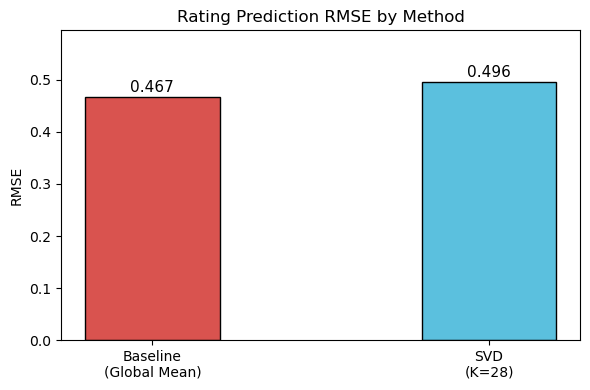

In [49]:
# --- Bar chart comparing RMSE across methods ---
methods = ['Baseline\n(Global Mean)', f'SVD\n(K={K_eval})']
rmses   = [rmse_baseline, rmse_svd]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, rmses, color=['#d9534f', '#5bc0de'], edgecolor='black', width=0.4)
plt.ylabel('RMSE')
plt.title('Rating Prediction RMSE by Method')
plt.ylim(0, max(rmses) * 1.2)
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()